In [31]:
#importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
#ML libraries

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


In [33]:
#DATA LOADING  

df = pd.read_csv("C:\\Users\\AKASH ANTONY\\OneDrive\\Desktop\\project\\framingham_expanded.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (8000, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,71,1,1,37,1,0,0,1,167,173,118,23.990634,118,96,1
1,1,50,4,0,37,0,0,1,1,316,120,70,32.847120,113,199,1
2,0,66,3,1,3,1,1,1,1,265,154,110,35.689509,60,133,1
3,0,56,2,1,17,1,0,1,0,324,179,91,22.334151,55,145,1
4,0,58,3,0,9,1,1,1,0,176,178,83,39.409364,51,124,1


In [34]:
#BASIC CHECKS

print("Missing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['TenYearCHD'].value_counts())


Missing values:
 male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

Target distribution:
 TenYearCHD
1    6668
0    1332
Name: count, dtype: int64


In [35]:
#ADDING REALISTIC NOISE TO NUMERICAL COLUMNS

np.random.seed(42)

noise_cols = ['sysBP', 'diaBP', 'totChol', 'BMI', 'glucose']

for col in noise_cols:
    df[col] = df[col] + np.random.normal(
        0, df[col].std() * 0.05, size=df.shape[0]
    )


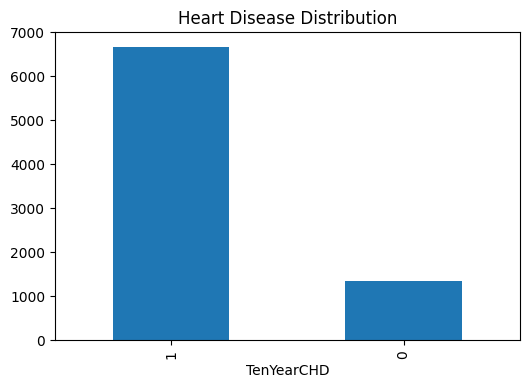

In [36]:
#EDA GRAPHS

df['TenYearCHD'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Heart Disease Distribution")
plt.show()


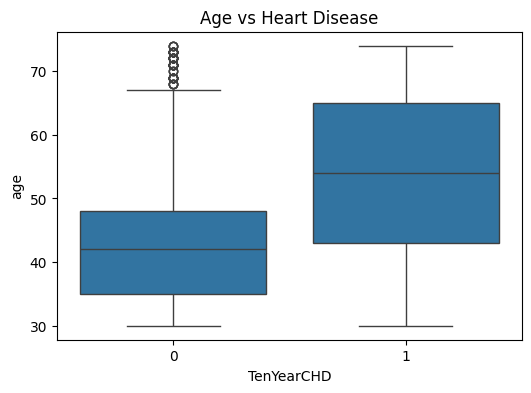

In [37]:
# Age vs Heart Disease


plt.figure(figsize=(6,4))
sns.boxplot(x='TenYearCHD', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

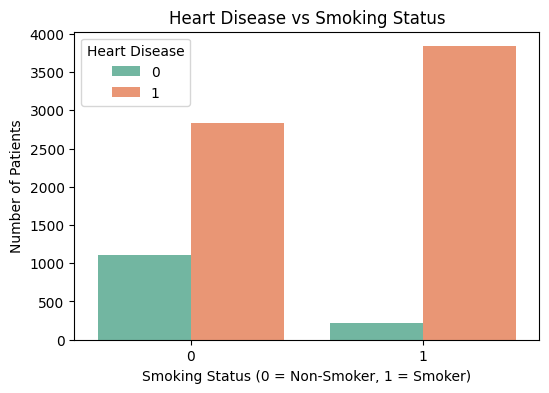

In [38]:
#HEART DISEASE vs SMOKING STATUS

plt.figure(figsize=(6,4))
sns.countplot(x='currentSmoker', hue='TenYearCHD', data=df, palette='Set2')
plt.title("Heart Disease vs Smoking Status")
plt.xlabel("Smoking Status (0 = Non-Smoker, 1 = Smoker)")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")
plt.show()


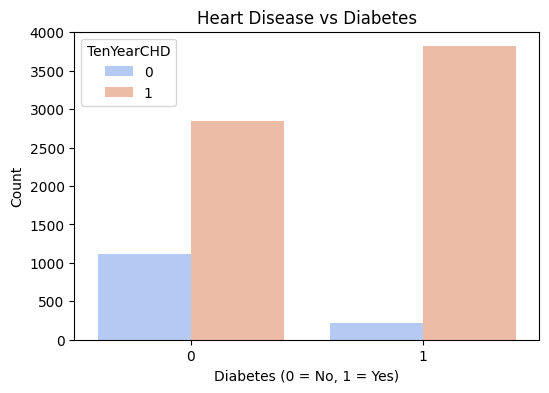

In [39]:
#HEART DISEASE VS DIABETES STATUS

plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', hue='TenYearCHD', data=df, palette='coolwarm')
plt.title("Heart Disease vs Diabetes")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


C:\Users\AKASH ANTONY\AppData\Local\Temp\ipykernel_20416\3793127210.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='TenYearCHD', y='BMI', data=df, palette='muted')


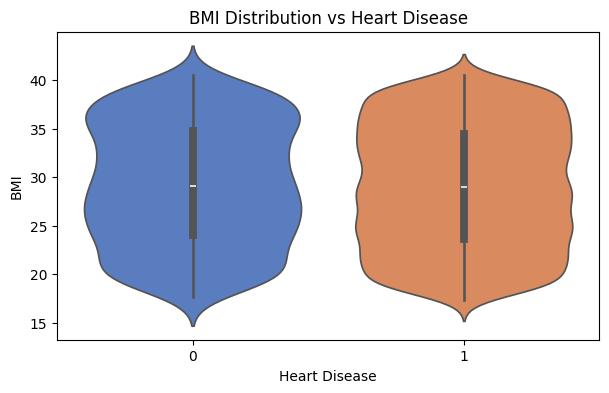

In [40]:
#BMI COMPARISON

plt.figure(figsize=(7,4))
sns.violinplot(x='TenYearCHD', y='BMI', data=df, palette='muted')
plt.title("BMI Distribution vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("BMI")
plt.show()


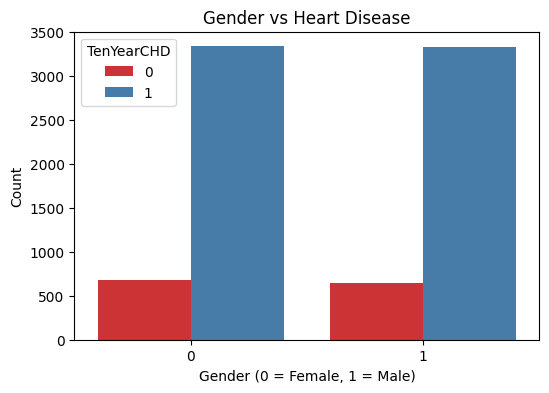

In [41]:
#GENDER VS HEART DISEASE

plt.figure(figsize=(6,4))
sns.countplot(x='male', hue='TenYearCHD', data=df, palette='Set1')
plt.title("Gender vs Heart Disease")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()


C:\Users\AKASH ANTONY\AppData\Local\Temp\ipykernel_20416\2914867351.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TenYearCHD', y='cigsPerDay', data=df, palette='cool')


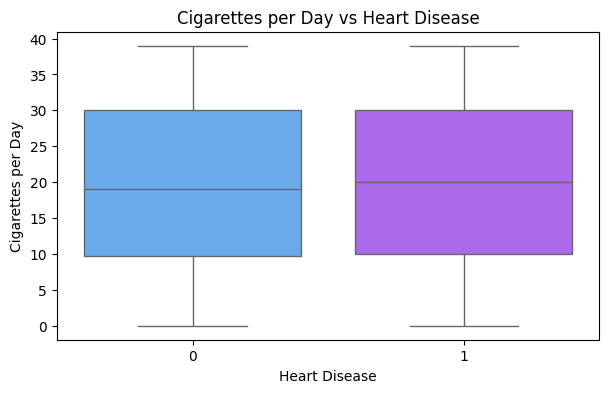

In [42]:
#SMOKERS VS HEART DISEASE

plt.figure(figsize=(7,4))
sns.boxplot(x='TenYearCHD', y='cigsPerDay', data=df, palette='cool')
plt.title("Cigarettes per Day vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cigarettes per Day")
plt.show()


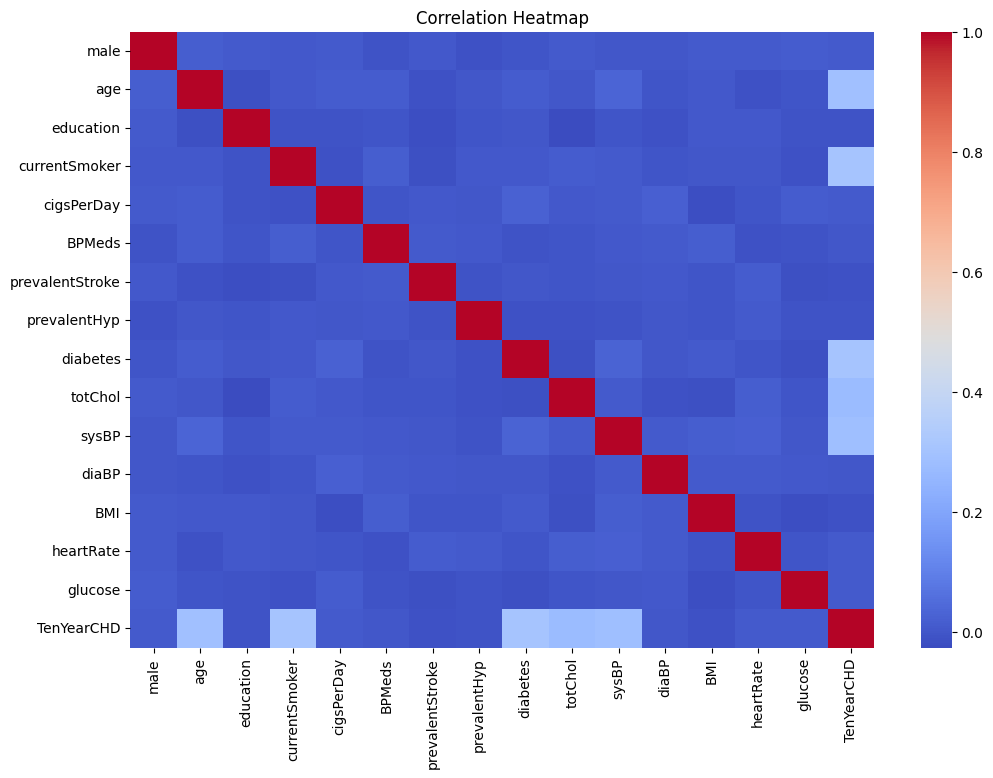

In [43]:
# Correlation heatmap


plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [44]:
#FEATURE AND TARGET SEPARATION

X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']


In [45]:
#STRATIFIED SPLIT

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [46]:
#SCALING

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [47]:
#MACHINE LEARNING MODELS

In [48]:
#RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_split=12,
    min_samples_leaf=8,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.955625


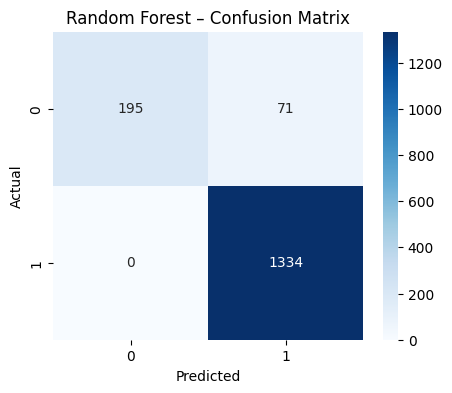

In [49]:
#CONFUSION MATRIX(BLUE HEAT MAP)

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


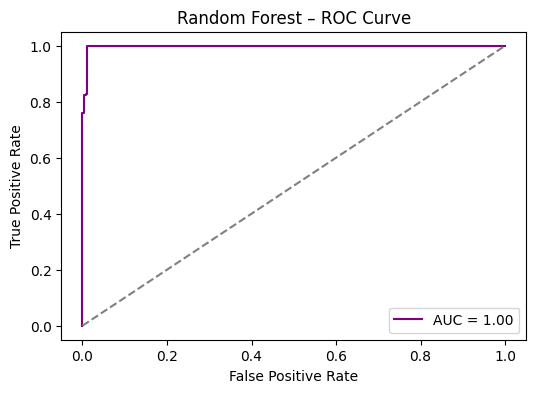

In [50]:
#ROC Curve (Step Style)

rf_probs = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.step(fpr, tpr, where='post', color='purple', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.title("Random Forest – ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


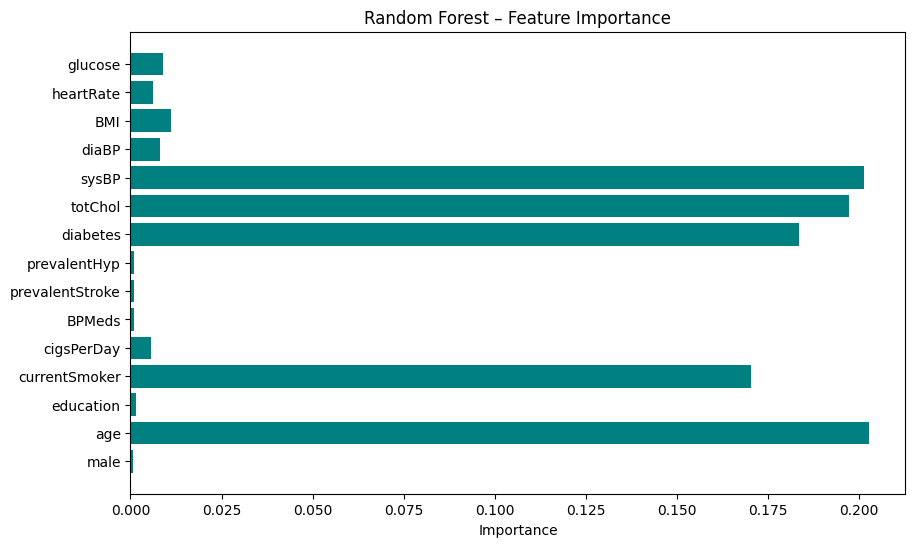

In [51]:
#Feature Importance (Bar Chart)

plt.figure(figsize=(10,6))
plt.barh(X.columns, rf.feature_importances_, color='teal')
plt.title("Random Forest – Feature Importance")
plt.xlabel("Importance")
plt.show()


In [52]:
#LOGISTIC REGRESSION


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.94


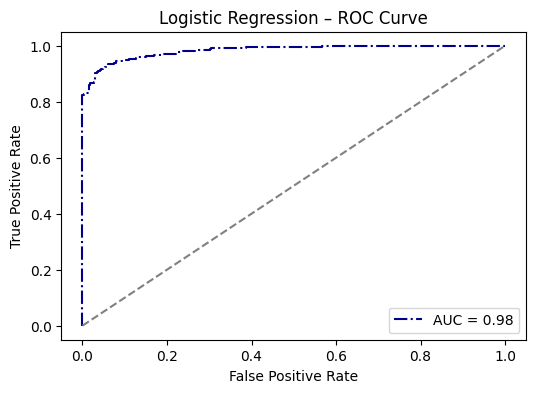

In [53]:
#ROC Curve (Dashed Style)

lr_probs = lr.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, lr_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, linestyle='-.', color='darkblue', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.title("Logistic Regression – ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


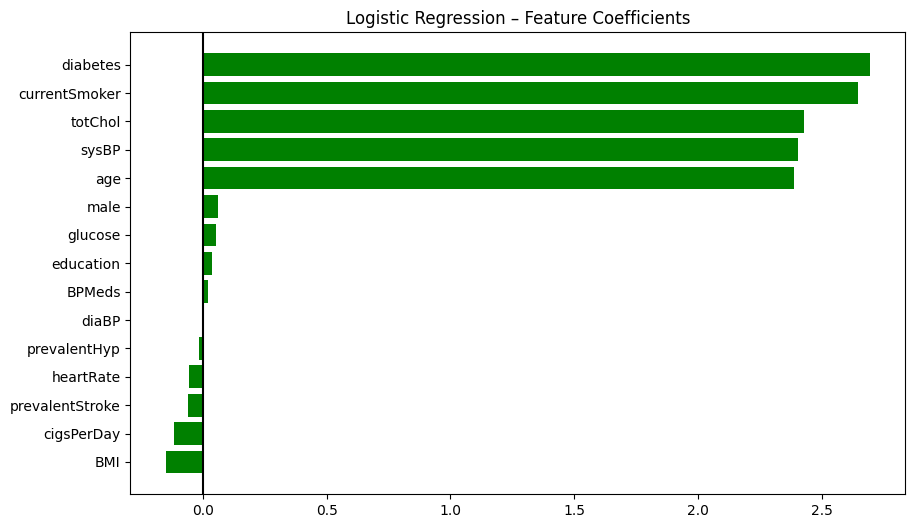

In [54]:
#Coefficient Plot (Interpretability Graph)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient')

plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='green')
plt.axvline(0, color='black')
plt.title("Logistic Regression – Feature Coefficients")
plt.show()


In [55]:
#SVM

svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))


SVM Accuracy: 0.944375


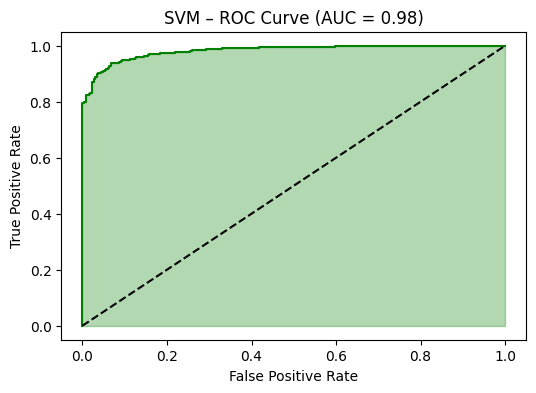

In [56]:
#ROC Curve (Filled Area Style)

svm_probs = svm.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, svm_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='green')
plt.fill_between(fpr, tpr, alpha=0.3, color='green')
plt.plot([0,1], [0,1], '--', color='black')
plt.title(f"SVM – ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


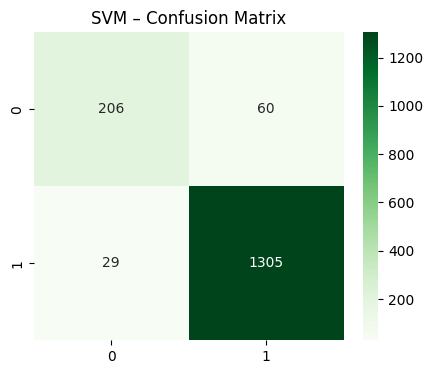

In [57]:
#Confusion Matrix (Green Theme)

svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Greens')
plt.title("SVM – Confusion Matrix")
plt.show()

In [58]:
#KNN

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))


KNN Accuracy: 0.91625


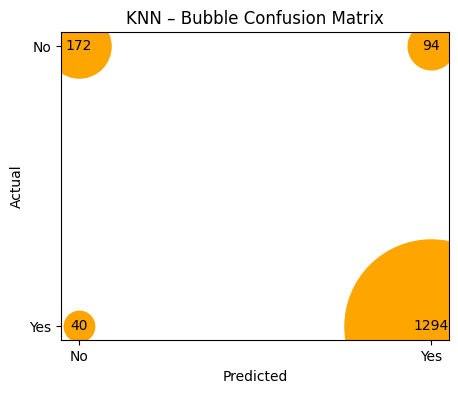

In [59]:
#Bubble Confusion Matrix (Unique Style)

knn_cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))
for i in range(2):
    for j in range(2):
        plt.scatter(j, i, s=knn_cm[i,j]*12, color='orange')
        plt.text(j, i, knn_cm[i,j], ha='center', va='center')

plt.xticks([0,1], ['No','Yes'])
plt.yticks([0,1], ['No','Yes'])
plt.gca().invert_yaxis()
plt.title("KNN – Bubble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


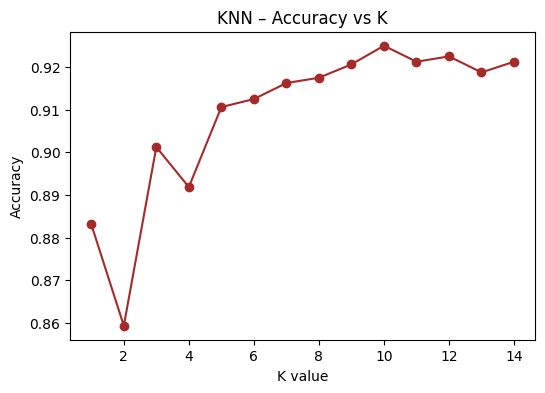

In [60]:
#Accuracy vs K (Optional but Impressive)

accs = []
ks = range(1, 15)

for k in ks:
    temp_knn = KNeighborsClassifier(n_neighbors=k)
    temp_knn.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, temp_knn.predict(X_test)))

plt.figure(figsize=(6,4))
plt.plot(ks, accs, marker='o', color='brown')
plt.title("KNN – Accuracy vs K")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.show()


In [61]:
#DEEP LEARNING MODELS (Optional)

In [62]:
#TENSORFLOW IMPORTS

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [63]:
#MLP MODEL (USES SAME STRATIFIED DATA)

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


C:\Users\AKASH ANTONY\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
#TRAIN WITH EPOCHS

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=35,
    validation_split=0.2,
    verbose=1
)


Epoch 1/60
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8262 - loss: 0.3866 - val_accuracy: 0.9047 - val_loss: 0.2140
Epoch 2/60
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8979 - loss: 0.2187 - val_accuracy: 0.9406 - val_loss: 0.1384
Epoch 3/60
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9111 - loss: 0.1943 - val_accuracy: 0.9430 - val_loss: 0.1287
Epoch 4/60
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9252 - loss: 0.1705 - val_accuracy: 0.9461 - val_loss: 0.1289
Epoch 5/60
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9268 - loss: 0.1641 - val_accuracy: 0.9438 - val_loss: 0.1226
Epoch 6/60
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9309 - loss: 0.1548 - val_accuracy: 0.9430 - val_loss: 0.1228
Epoch 7/60
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9328 - loss: 0.1540 - val_accuracy: 0.9461 - val_loss: 0.1239
Epoch 8/60
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9342 - loss: 0.1440 - val_accuracy: 0.

In [65]:
#EVALUATION

test_loss, test_acc = model.evaluate(X_test, y_test)
print("TensorFlow MLP Accuracy:", test_acc)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9569 - loss: 0.1041
TensorFlow MLP Accuracy: 0.9568750262260437


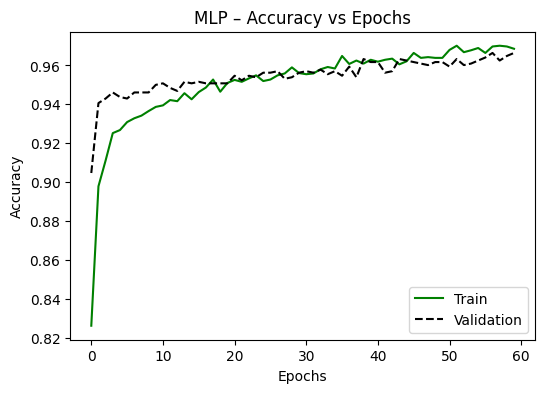

In [66]:
#ACCURACY VS EPOCHS

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train', color='green')
plt.plot(history.history['val_accuracy'], '--', label='Validation', color='black')
plt.title("MLP – Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


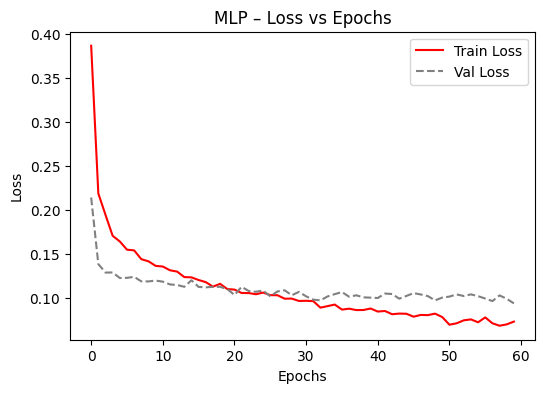

In [67]:
#LOSS VS EPOCHS

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], '--', label='Val Loss', color='gray')
plt.title("MLP – Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [68]:
#USER INPUT

def predict_heart_disease():
    print("Enter patient details:")

    user_data = np.array([[ 
        int(input("Gender (1=Male,0=Female): ")),
        int(input("Age: ")),
        int(input("Education (1–4): ")),
        int(input("Smoker (1=Yes,0=No): ")),
        int(input("Cigs/day: ")),
        int(input("BP Meds (1=Yes,0=No): ")),
        int(input("Stroke (1=Yes,0=No): ")),
        int(input("Hypertension (1=Yes,0=No): ")),
        int(input("Diabetes (1=Yes,0=No): ")),
        float(input("Cholesterol: ")),
        float(input("Sys BP: ")),
        float(input("Dia BP: ")),
        float(input("BMI: ")),
        float(input("Heart Rate: ")),
        float(input("Glucose: "))
    ]])

    user_data = scaler.transform(user_data)
    prob = model.predict(user_data)[0][0]

    print(f"\nHeart Disease Risk Probability: {prob:.2f}")
    print("⚠️ High Risk" if prob >= 0.5 else "✅ Low Risk")


In [70]:
predict_heart_disease()

Enter patient details:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Heart Disease Risk Probability: 1.00
⚠️ High Risk


C:\Users\AKASH ANTONY\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
